In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("/content/sample_data/swiggy_vs_zomato_3000.csv")

In [3]:
print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

  restaurant_id restaurant_name    city            locality restaurant_type  \
0    REST000001    Restaurant_1  Mumbai   Mumbai_Locality_9            Cafe   
1    REST000002    Restaurant_2  Mumbai  Mumbai_Locality_13   Casual Dining   
2    REST000003    Restaurant_3  Mumbai  Mumbai_Locality_12       Fine Dine   
3    REST000004    Restaurant_4  Mumbai  Mumbai_Locality_19   Cloud Kitchen   
4    REST000005    Restaurant_5  Mumbai  Mumbai_Locality_13            Cafe   

        cuisines  distance_from_city_center_km opening_time closing_time  \
0        Italian                           4.1        12:00        22:00   
1        Mughlai                           1.9        09:00        23:00   
2  Mediterranean                           2.9        08:00        23:00   
3       Desserts                          13.2        08:00        23:00   
4        Mexican                           6.0        11:00        23:00   

   days_operational  ...  swiggy_market_share_pct  zomato_market_sha

In [4]:
bool_cols = [
    'has_own_website',
    'has_own_app',
    'food_license_verified'
]

for col in bool_cols:
    df[col] = df[col].map({'TRUE': 1, 'FALSE': 0})

In [6]:
df['listing_date'] = pd.to_datetime(df['listing_date'], format='%Y-%m-%d')

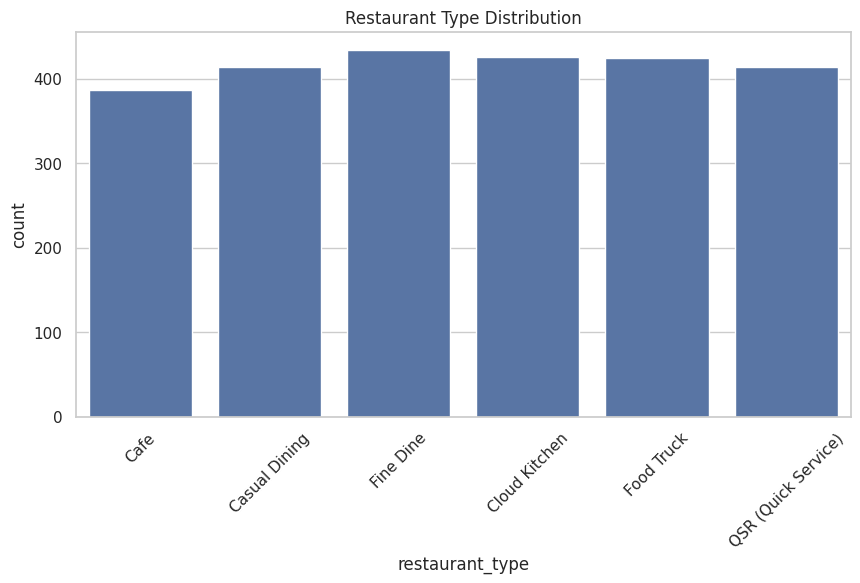

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='restaurant_type')
plt.xticks(rotation=45)
plt.title("Restaurant Type Distribution")
plt.show()

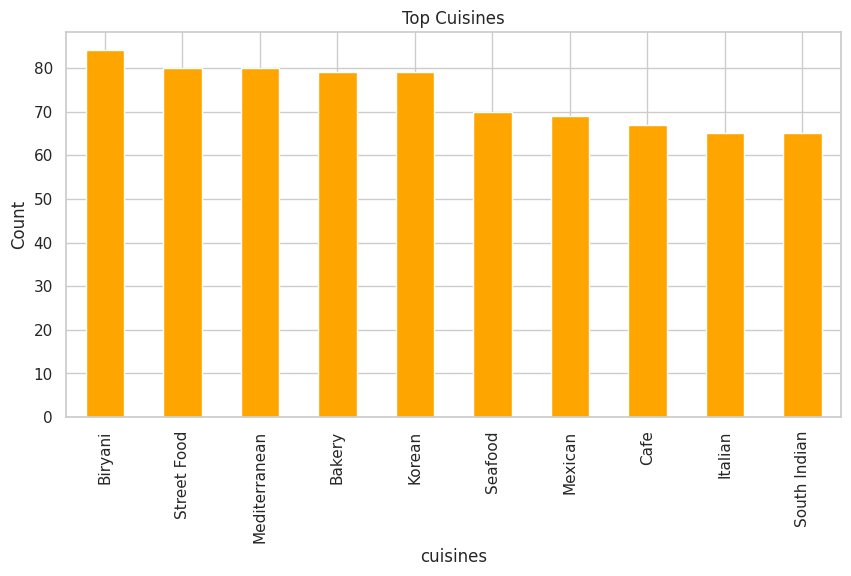

In [8]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_cuisines.plot(kind='bar', color='orange')
plt.title("Top Cuisines")
plt.ylabel("Count")
plt.show()

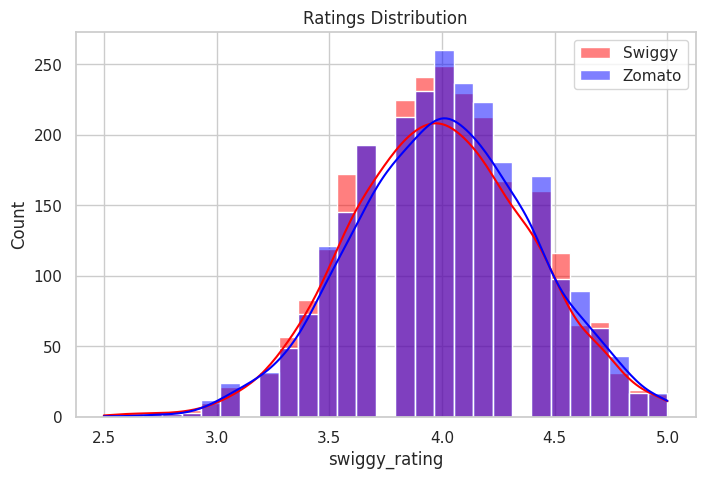

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['swiggy_rating'], color='red', label='Swiggy', kde=True)
sns.histplot(df['zomato_rating'], color='blue', label='Zomato', kde=True)

plt.legend()
plt.title("Ratings Distribution")
plt.show()

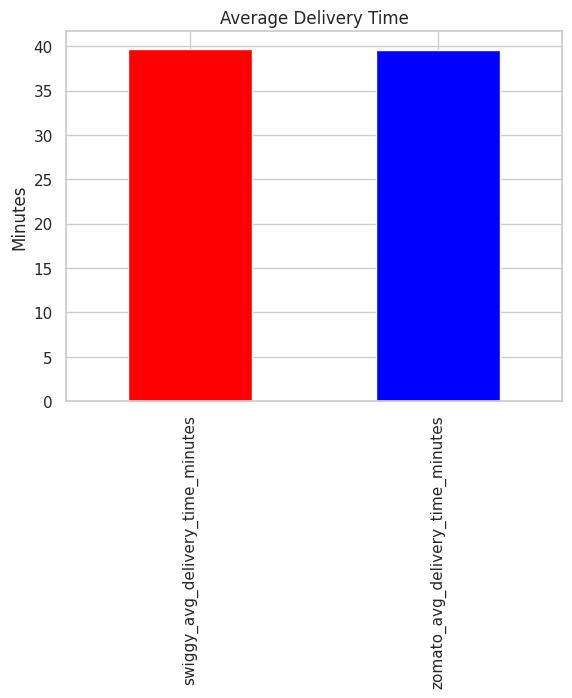

In [10]:
delivery = df[[
    'swiggy_avg_delivery_time_minutes',
    'zomato_avg_delivery_time_minutes'
]].mean()

delivery.plot(kind='bar', color=['red', 'blue'])

plt.ylabel("Minutes")
plt.title("Average Delivery Time")
plt.show()

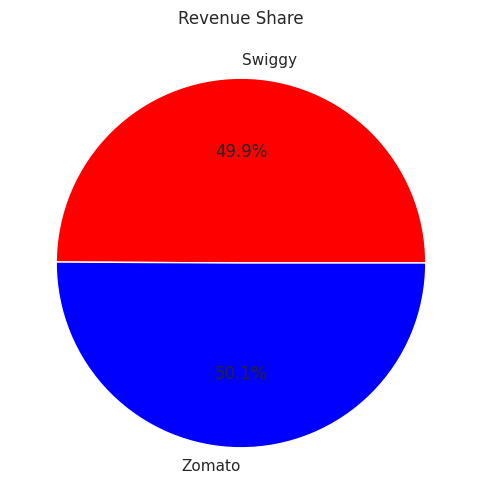

In [11]:
platform_revenue = {
    'Swiggy': df['swiggy_estimated_monthly_revenue_inr'].sum(),
    'Zomato': df['zomato_estimated_monthly_revenue_inr'].sum()
}

plt.figure(figsize=(6,6))
plt.pie(
    platform_revenue.values(),
    labels=platform_revenue.keys(),
    autopct='%1.1f%%',
    colors=['red', 'blue']
)

plt.title("Revenue Share")
plt.show()

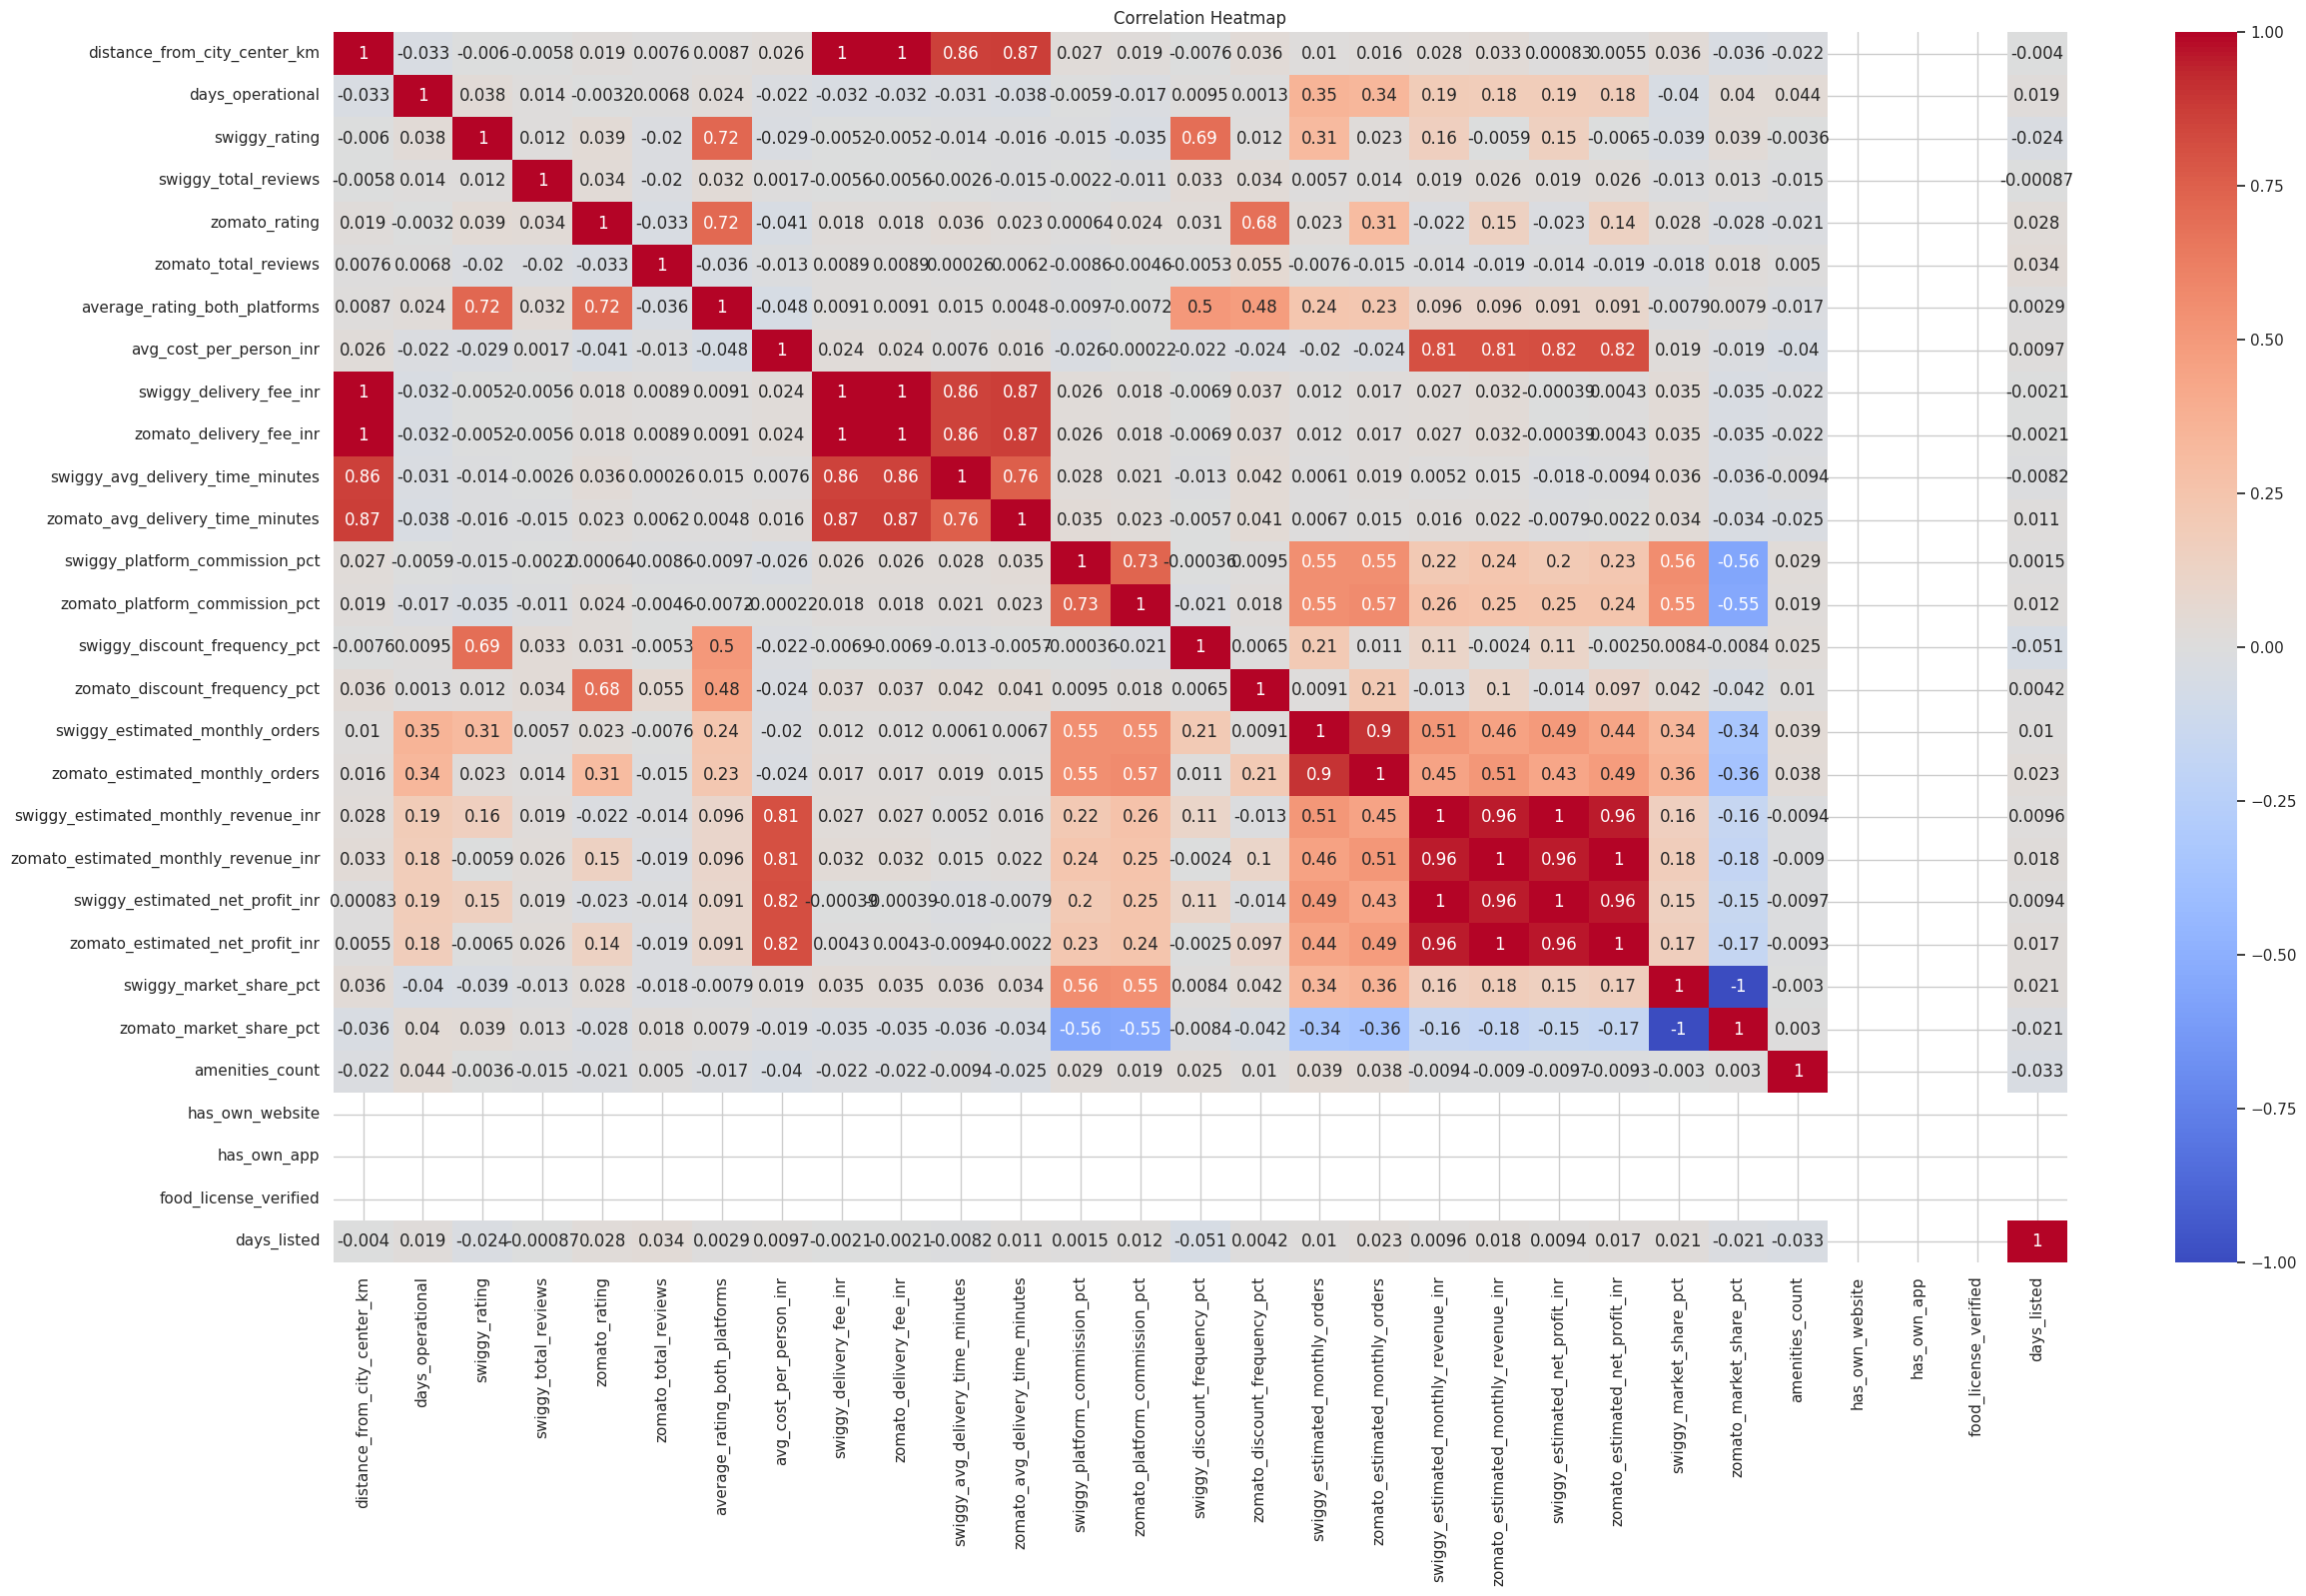

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(28,16))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
top_restaurants = df.sort_values(
    by='average_rating_both_platforms',
    ascending=False
)

print(top_restaurants[[
    'restaurant_name',
    'average_rating_both_platforms',
    'swiggy_estimated_monthly_revenue_inr',
    'zomato_estimated_monthly_revenue_inr'
]].head(10))

      restaurant_name  average_rating_both_platforms  \
315    Restaurant_316                           4.90   
343    Restaurant_344                           4.85   
1671  Restaurant_1672                           4.85   
79      Restaurant_80                           4.80   
2440  Restaurant_2441                           4.80   
2212  Restaurant_2213                           4.75   
1033  Restaurant_1034                           4.75   
1852  Restaurant_1853                           4.75   
1978  Restaurant_1979                           4.75   
526    Restaurant_527                           4.75   

      swiggy_estimated_monthly_revenue_inr  \
315                                 266079   
343                                 280330   
1671                                193549   
79                                   81685   
2440                                160769   
2212                                 90186   
1033                                245700   
1852           

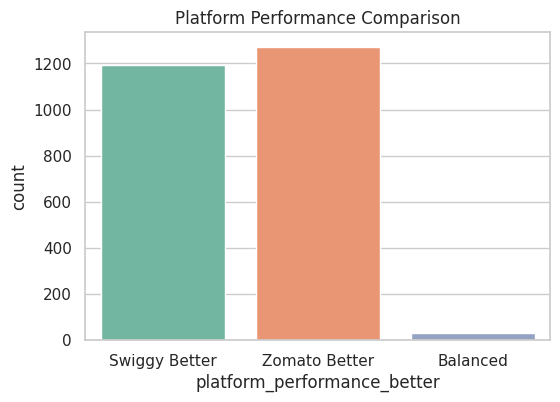

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='platform_performance_better',
    palette='Set2'
)

plt.title("Platform Performance Comparison")
plt.show()

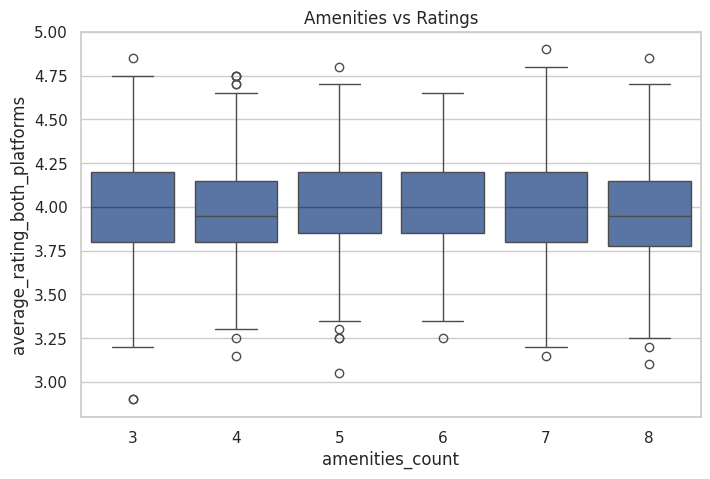

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='amenities_count',
    y='average_rating_both_platforms'
)

plt.title("Amenities vs Ratings")
plt.show()

In [17]:
df['total_revenue'] = (
    df['swiggy_estimated_monthly_revenue_inr'] +
    df['zomato_estimated_monthly_revenue_inr']
)

In [18]:
df['total_orders'] = (
    df['swiggy_estimated_monthly_orders'] +
    df['zomato_estimated_monthly_orders']
)

In [19]:
features = [
    'distance_from_city_center_km',
    'days_operational',
    'swiggy_rating',
    'zomato_rating',
    'avg_cost_per_person_inr',
    'swiggy_avg_delivery_time_minutes',
    'zomato_avg_delivery_time_minutes',
    'amenities_count',
    'has_own_website',
    'has_own_app',
    'food_license_verified'
]

X = df[features]
y = df['total_revenue']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [23]:
predictions = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 60272.69804
R2 Score: 0.7294087862417944


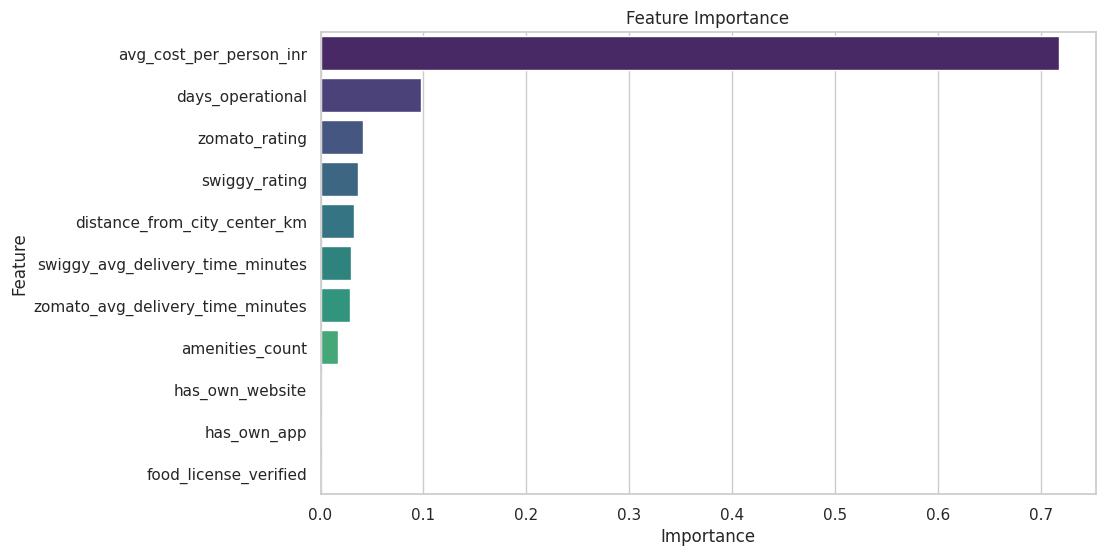

In [25]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Feature Importance")
plt.show()

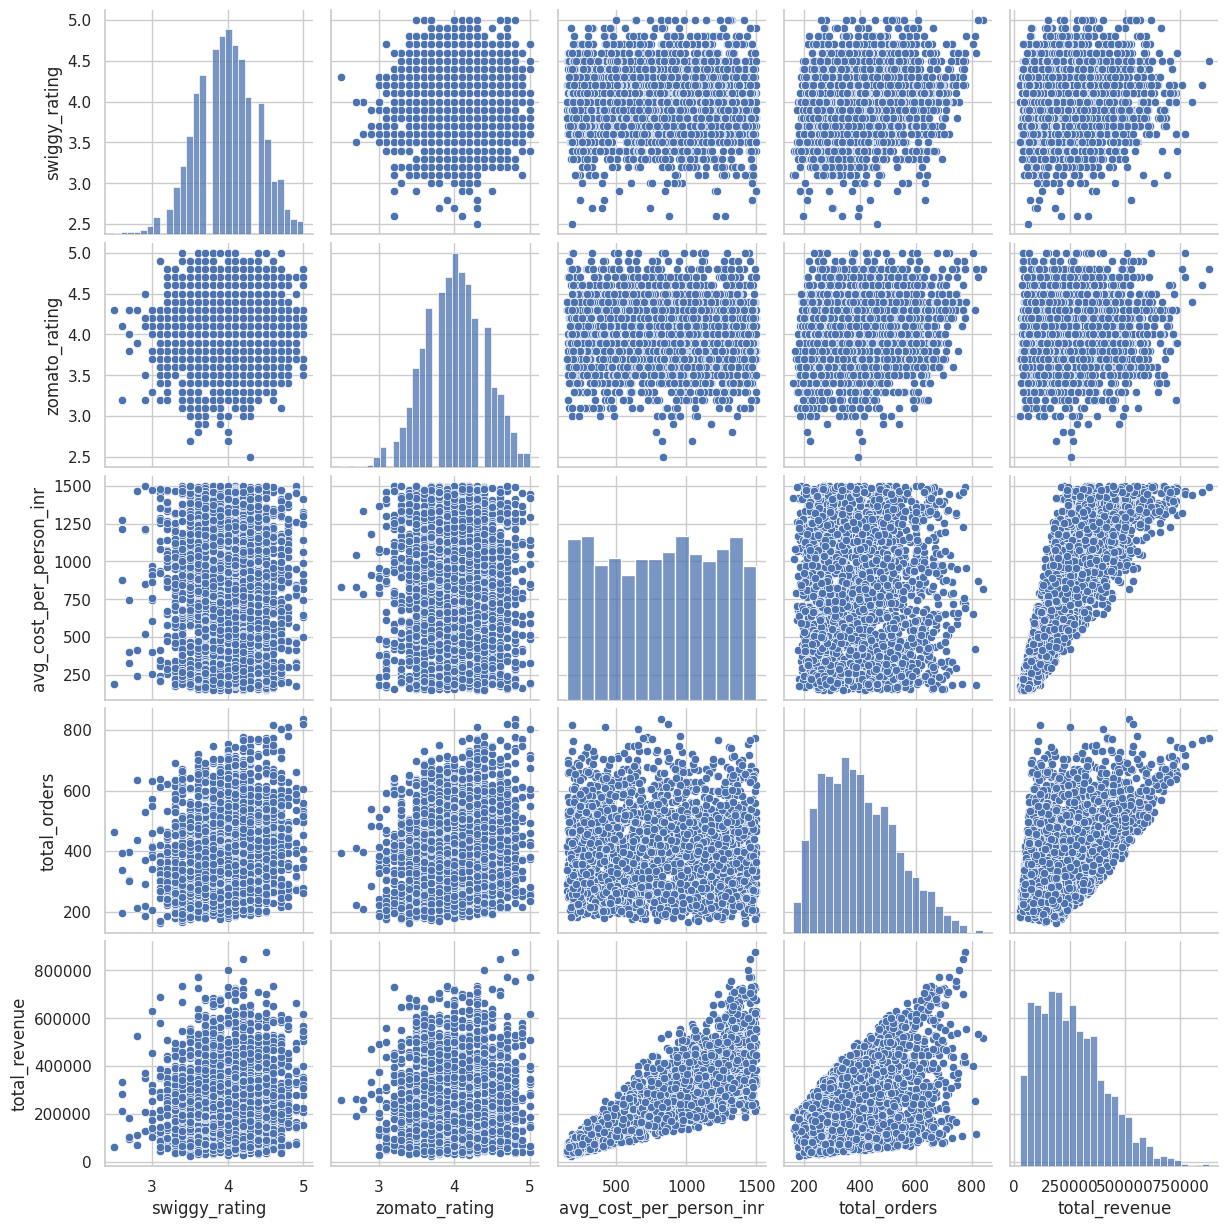

In [26]:
sns.pairplot(df[[
    'swiggy_rating',
    'zomato_rating',
    'avg_cost_per_person_inr',
    'total_orders',
    'total_revenue'
]])

plt.show()

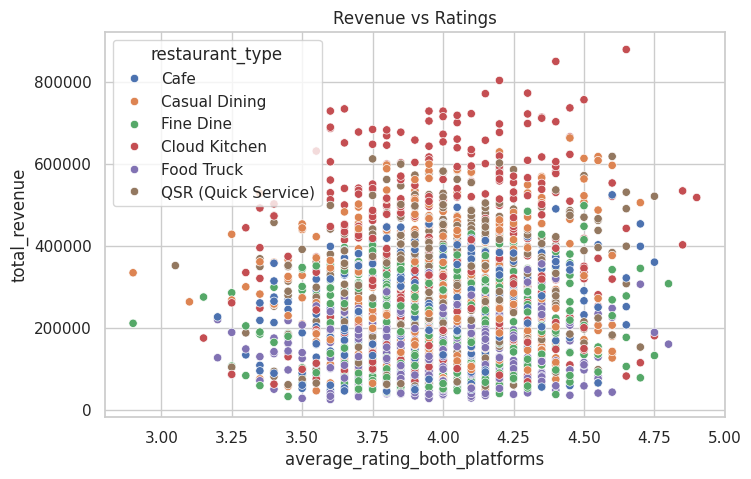

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='average_rating_both_platforms',
    y='total_revenue',
    hue='restaurant_type'
)

plt.title("Revenue vs Ratings")
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[[
    'average_rating_both_platforms',
    'total_orders',
    'total_revenue'
]]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled)

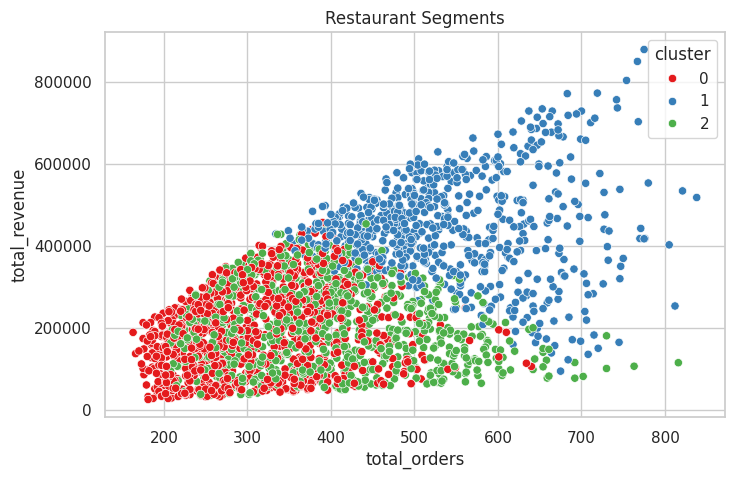

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='total_orders',
    y='total_revenue',
    hue='cluster',
    palette='Set1'
)

plt.title("Restaurant Segments")
plt.show()